# Which topics are the most structurally important in the online network of information about U.S. healthcare costs and health insurance?

### Outside Sources:
I used Wikepedia pages as my nodes and their hyper links for the paths
I used ChatGPT to help troubleshoot Python code and clarify NetworkX functions. I validated the output by running the code myself, manually checking several hyperlinks, inspecting the dataset, and verifying that the NetworkX functions produced reasonable results.

### Limitations:
You only analyzed a subset of Wikipedia.
Your starting pages influence which pages appear in the network.
Wikipedia's links reflect editorial decisions.
A hyperlink does not necessarily mean a topic is medically or economically more important.
PageRank measures structural importance, not patient importance.
Wikipedia changes over time.

## Stakeholder: A patient-education nonprofit or hospital financial counseling department.
## Decision: The organization wants to create an online guide explaining healthcare costs and insurance and needs to decide which concepts should be introduced first and linked most prominently.

### Links
1.https://en.wikipedia.org/wiki/Health_economics 
2.https://en.wikipedia.org/wiki/Health_insurance_in_the_United_States
3.https://en.wikipedia.org/wiki/Medicare_(United_States)
4.http://en.wikipedia.org/wiki/Medicaid
5.https://en.wikipedia.org/wiki/Medical_debt
6.https://en.wikipedia.org/wiki/Prescription_drug_prices_in_the_United_States
7.https://en.wikipedia.org/wiki/Affordable_Care_Act
8.http://en.wikipedia.org/wiki/Health_care_prices_in_the_United_States
9.https://en.wikipedia.org/wiki/Health_insurance_in_the_United_States


In [6]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [7]:
pages = [
    "Health_economics",
    "Health_insurance_in_the_United_States",
    "Healthcare_in_the_United_States",
    "Medicare_(United_States)",
    "Medicaid",
    "Medical_debt",
    "Prescription_drug_prices_in_the_United_States",
    "Affordable_Care_Act"
]

In [10]:
import requests

url = "https://en.wikipedia.org/wiki/Health_economics"

headers = {
    "User-Agent": "INST414HealthcareNetwork/1.0 (student research project)"
}

response = requests.get(url, headers=headers)

print(response.status_code)

200


In [11]:
from bs4 import BeautifulSoup

soup = BeautifulSoup(response.text, "html.parser")
links = soup.find_all("a")

print(len(links))

983


In [19]:
response = requests.get(url, headers=headers)

In [20]:
edges = []

In [21]:
for page in pages:
    
    url = "https://en.wikipedia.org/wiki/" + page
    
    response = requests.get(url, headers=headers)
    
    print(page, response.status_code)

Health_economics 200
Health_insurance_in_the_United_States 200
Healthcare_in_the_United_States 200
Medicare_(United_States) 200
Medicaid 200
Medical_debt 200
Prescription_drug_prices_in_the_United_States 200
Affordable_Care_Act 200


In [22]:
edges = []

for page in pages:
    
    url = "https://en.wikipedia.org/wiki/" + page
    
    response = requests.get(url, headers=headers)
    
    soup = BeautifulSoup(response.text, "html.parser")
    
    links = soup.find_all("a")
    
    for link in links:
        
        href = link.get("href")
        
        if href and href.startswith("/wiki/"):
            
            target = href.replace("/wiki/", "")
            
            edges.append([page, target])

In [23]:
len(edges)

407

In [24]:
edges[:10]

[['Health_economics', 'Main_Page'],
 ['Health_economics', 'Wikipedia:Contents'],
 ['Health_economics', 'Portal:Current_events'],
 ['Health_economics', 'Special:Random'],
 ['Health_economics', 'Wikipedia:About'],
 ['Health_economics', 'Help:Contents'],
 ['Health_economics', 'Help:Introduction'],
 ['Health_economics', 'Wikipedia:Community_portal'],
 ['Health_economics', 'Special:RecentChanges'],
 ['Health_economics', 'Wikipedia:File_upload_wizard']]

In [25]:
df = pd.DataFrame(edges, columns=["source", "target"])

In [27]:
df = df.drop_duplicates()

In [28]:
df.shape

(24, 2)

In [29]:
df.head(20)

,source,target
0,Health_economics,Main_Page
2,Health_economics,Portal:Current_events
13,Health_economics,Health_economics
36,Health_insurance_in_the_United_States,Main_Page
38,Health_insurance_in_the_United_States,Portal:Current_events
49,Health_insurance_in_the_United_States,Health_insurance_in_the_United_States
86,Healthcare_in_the_United_States,Main_Page
88,Healthcare_in_the_United_States,Portal:Current_events
99,Healthcare_in_the_United_States,Healthcare_in_the_United_States
149,Medicare_(United_States),Main_Page


In [31]:
df.to_csv("data/healthcare_links.csv", index=False)

In [32]:
G = nx.from_pandas_edgelist(
    df,
    source="source",
    target="target",
    create_using=nx.DiGraph()
)

In [33]:
G.number_of_nodes()

10

In [34]:
G.number_of_edges()

24

In [35]:
pagerank = nx.pagerank(G)

In [36]:
results = pd.DataFrame(
    pagerank.items(),
    columns=["page", "pagerank"]
)

results = results.sort_values(
    "pagerank",
    ascending=False
)

In [37]:
results.head(10)

,page,pagerank
1,Main_Page,0.213605
2,Portal:Current_events,0.213605
0,Health_economics,0.071599
3,Health_insurance_in_the_United_States,0.071599
4,Healthcare_in_the_United_States,0.071599
5,Medicare_(United_States),0.071599
6,Medicaid,0.071599
7,Medical_debt,0.071599
8,Prescription_drug_prices_in_the_United_States,0.071599
9,Affordable_Care_Act,0.071599


In [38]:
betweenness = nx.betweenness_centrality(G)

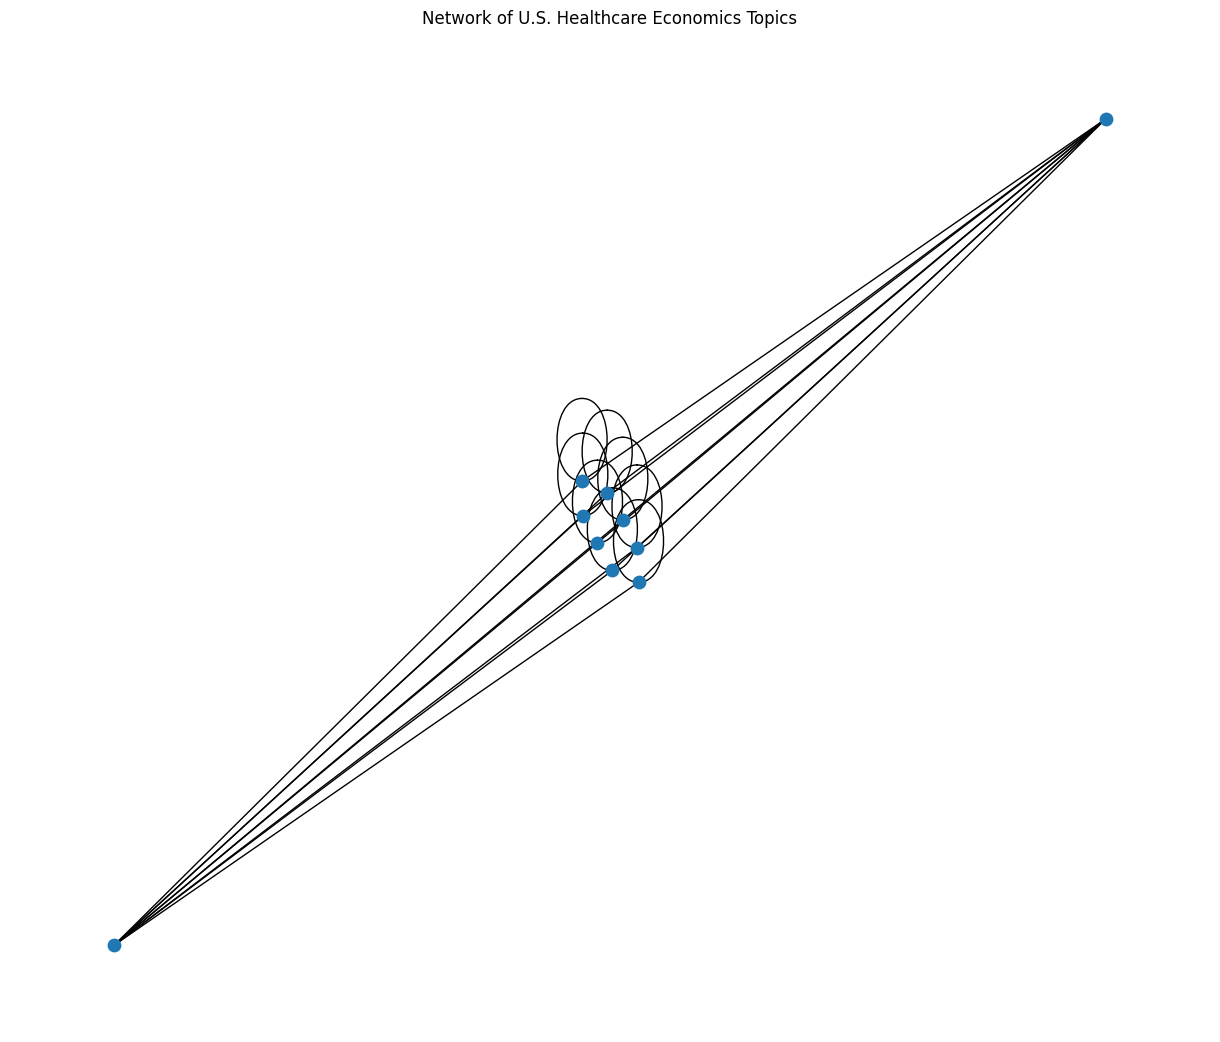

In [39]:
plt.figure(figsize=(12, 10))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    node_size=80,
    arrows=False
)

plt.title("Network of U.S. Healthcare Economics Topics")
plt.savefig("figures/network.png", bbox_inches="tight")
plt.show()

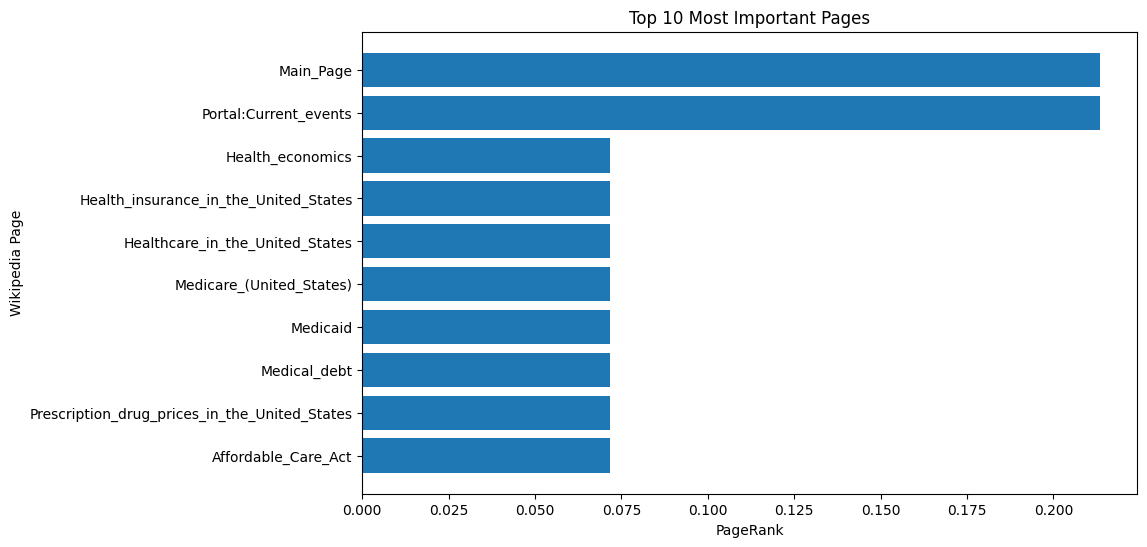

In [40]:
top10 = results.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10["page"], top10["pagerank"])
plt.xlabel("PageRank")
plt.ylabel("Wikipedia Page")
plt.title("Top 10 Most Important Pages")
plt.gca().invert_yaxis()
plt.savefig("figures/top10_pagerank.png", bbox_inches="tight")
plt.show()